# Global Sensitivity Analysis for Microglial Insulin Signaling Model
## A$\beta$ Plaque Dynamics with Insulin-Modulated Clearance

### Design principles
- **Equations** transcribed verbatim from Eqs. (1)-(4) of the manuscript.
- **3 state variables**: $S$ (soluble A$\beta$), $P$ (plaque-associated A$\beta$), $\Gamma$ (microglial inflammatory tone).
- **15 GSA parameters**: 14 model parameters plus $I$ (insulin signaling, the central control parameter). Each is varied an order of magnitude in each direction, except $I$ (over [0.3, 1.0], its physiological range) and $n$ (over [1, 6], its literature range).
- **GSA outputs**: final $S$, $P$, $\Gamma$, and $U(I,\Gamma)$.

### Sample-size accounting (read this before changing N_BASE)
Sampling uses `saltelli.sample(problem, N_BASE, calc_second_order=False)`. In that
mode SALib generates

$$ N_\text{runs} = (D + 2)\, N_\text{BASE}, \qquad D = 15 \;\Rightarrow\; N_\text{runs} = 17\, N_\text{BASE}. $$

**69,632 parameter sets**, which is exactly $17 \times 4096$, so the reported run
uses `N_BASE = 4096`. That is the default set below.

### NRP_SWITCH locations
Search `# NRP_SWITCH` which appears in **Cell: Sample Size** (N_BASE) and **Cell: Parallel ODE Solves** (Numba threads).


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol
import numba as nb
from numbalsoda import lsoda_sig, lsoda
import time

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})
BAR_BLUE = 'blue'
BAR_CYAN = 'cyan'
print('Imports OK')

Imports OK


## 2. Sample Size - LOCAL vs NRP

In [2]:
# ============================================================
# NRP_SWITCH
# N_PARAMS = 15 (see "GSA Parameter Vector" below)
# Total solves = (D + 2) * N_BASE = (15 + 2) * N_BASE = 17 * N_BASE
#   (multiplier is 17 because calc_second_order=False;
#    it would be 2*D+2 = 32 only with calc_second_order=True)
#
# | Mode         | N_BASE | Total solves (= 17 * N_BASE) |
# |--------------|--------|------------------------------|
# | Local test   |     64 |                        1,088 |
# | Local medium |    256 |                        4,352 |
# | NRP full     |   2048 |                       34,816 |
# | NRP high-res |   4096 |                       69,632 |  <- manuscript run
# ============================================================
# N_BASE = 64       # To test on LOCAL machine
N_BASE = 4096       # NRP high-res: reproduces the 69,632 sets reported in the paper
# ============================================================

MULTIPLIER = 17     # (D + 2) with D = 15 and calc_second_order=False
print(f'N_BASE = {N_BASE}')
print(f'Total solves will be {MULTIPLIER} * {N_BASE} = {MULTIPLIER * N_BASE}')


N_BASE = 4096
Total solves will be 17 * 4096 = 69632


## 3. Baseline Parameters and Derived Quantities

All values from Table 1 of the manuscript. Where parameters appear in calibration relations
($K_S=S_ss$, $K_P=P_ss$, $k_clr$ from $dP/dt=0$), we record both the baseline number and the derivation,
but treat all 15 as **independent** in the GSA.  Steady states are derived in Appendix B and justification for parameters is also in Appendix B.

In [3]:
# Fixed literature rates
p_S     = 7.34e-12 * 3600 * 1e12  # pM/hr  (Craft et al. 2002)
delta_S = 1.0                       # hr^-1
k_rel   = 1e-3                      # hr^-1
U_0     = 1.0                       # normalized baseline clearance efficiency
n       = 2                         # Hill exponent

# Insulin signaling
I_WT    = 1.0    # intact
I_IRKO  = 0.6    # impaired (~40% uptake reduction reported under IRKO, Chen et al. 2025)
I_base  = I_WT   # baseline for GSA reference run

# Inflammation parameters
delta_G = 0.006   # hr^-1  (~1 week decay)
k_S     = 0.003   # hr^-1  (soluble A-beta drives inflammation)
k_P     = 3e-4    # hr^-1
lam     = 0.5     # inflammation suppression of clearance
k_seed  = 1e-2    # hr^-1

# Calibrated steady-state targets (Craft et al. 2002)
monomer_frac = 0.013
S_ss = p_S / delta_S
P_ss = S_ss * (1 - monomer_frac) / monomer_frac

K_S   = S_ss     # half-sat for inflammation from S
K_P   = P_ss     # half-sat for inflammation from P
K     = P_ss * 0.20   # half-sat for Hill seeding
K_rel = K        # half-sat for plaque release (tied to K in the ODE)

# Approximate Gamma steady state used in k_clr derivation
G_approx = (k_S * 0.5 + k_P * 0.5) / delta_G
U_wt     = U_0 * I_WT / (1 + lam * G_approx)

# k_clr derived from dP/dt=0 at P=P_ss, I=1
k_clr   = k_seed * S_ss * P_ss / ((K**2 + P_ss**2) * U_wt)

print('Baseline parameter values:')
print(f'  p_S     = {p_S:.2f} pM/hr')
print(f'  delta_S = {delta_S}')
print(f'  k_seed  = {k_seed}')
print(f'  K       = {K:.0f} pM ({K/P_ss*100:.0f}% of P_ss)')
print(f'  k_rel   = {k_rel}')
print(f'  k_clr   = {k_clr:.4e}')
print(f'  U_0     = {U_0}')
print(f'  lam     = {lam}')
print(f'  k_S     = {k_S}   k_P = {k_P}')
print(f'  K_S     = {K_S:.0f}   K_P = {K_P:.0f}')
print(f'  delta_G = {delta_G}')
print(f'  n       = {n}')
print(f'  I_base  = {I_base}   (GSA range [0.3, 1.0])')
print()
print('Steady-state targets:')
print(f'  S_ss = {S_ss:.0f} pM')
print(f'  P_ss = {P_ss:.0f} pM')
print(f'  G_approx = {G_approx:.3f}')
print(f'  U_wt = {U_wt:.3f}')

Baseline parameter values:
  p_S     = 26424.00 pM/hr
  delta_S = 1.0
  k_seed  = 0.01
  K       = 401238 pM (20% of P_ss)
  k_rel   = 0.001
  k_clr   = 1.4406e-04
  U_0     = 1.0
  lam     = 0.5
  k_S     = 0.003   k_P = 0.0003
  K_S     = 26424   K_P = 2006191
  delta_G = 0.006
  n       = 2
  I_base  = 1.0   (GSA range [0.3, 1.0])

Steady-state targets:
  S_ss = 26424 pM
  P_ss = 2006191 pM
  G_approx = 0.275
  U_wt = 0.879


## 4. GSA Parameter Vector

**15 parameters** treated as independent. Order is critical - must match what the ODE unpacks.

Bounds: +/- 1 order of magnitude around baseline, with these exceptions:
- `I` in [0.3, 1.0] (physiologically constrained: 1.0 = intact, 0.3 covers severe impairment well below IRKO=0.6)
- `n` in [1, 6] (literature range; non-integer values permitted for continuity)
- `U_0` in [0.1, 10] (already normalized)

In [4]:
# GSA parameter vector - 15 parameters
# ORDER IS CRITICAL - must match what the ODE unpacks.
params_baseline = np.array([
    p_S,        # [0]  soluble A-beta production
    delta_S,    # [1]  soluble A-beta clearance
    k_seed,     # [2]  seeding rate
    K,          # [3]  half-saturation, seeding
    n,          # [4]  Hill exponent
    k_rel,      # [5]  plaque release rate
    k_clr,      # [6]  plaque clearance rate
    U_0,        # [7]  baseline clearance efficiency
    lam,        # [8]  inflammation suppression
    k_S,        # [9]  soluble inflammatory drive
    k_P,        # [10] plaque inflammatory drive
    K_S,        # [11] half-sat, S inflammation
    K_P,        # [12] half-sat, P inflammation
    delta_G,    # [13] microglial inflammatory decay
    I_base,     # [14] insulin signaling (control parameter)
])

N_PARAMS = len(params_baseline)
print(f'GSA parameter vector: {N_PARAMS} parameters')

GSA parameter vector: 15 parameters


## 5. ODE System - Eqs (1)-(4)

State vector (3 variables):
```
 0: S    soluble A-beta
 1: P    plaque-associated A-beta
 2: Gamma microglial inflammatory tone
```

In [5]:
@nb.cfunc(lsoda_sig)
def insulin_ode(t, y, du, p):
    '''
    Insulin signaling model, Eqs (1)-(4).
    Parameter vector: 15 entries (see Section 4).
    '''
    # State variables (clamp negatives)
    S = max(y[0], 0.0)
    P = max(y[1], 0.0)
    G = max(y[2], 0.0)

    # Unpack parameters
    p_ = nb.carray(p, (15,))
    p_S_     = p_[0]
    delta_S_ = p_[1]
    k_seed_  = p_[2]
    K_       = p_[3]
    n_       = p_[4]
    k_rel_   = p_[5]
    k_clr_   = p_[6]
    U_0_     = p_[7]
    lam_     = p_[8]
    k_S_     = p_[9]
    k_P_     = p_[10]
    K_S_     = p_[11]
    K_P_     = p_[12]
    delta_G_ = p_[13]
    I_       = p_[14]

    # Auxiliary quantities
    K_rel_ = K_
    U = U_0_ * I_ / (1.0 + lam_ * G)
    if P > 0.0:
        Pn = P ** n_
        Kn = K_ ** n_
        hill = Pn / (Kn + Pn)
    else:
        hill = 0.0
    rel = k_rel_ * P / (K_rel_ + P)

    # Eq (1): dS/dt
    du[0] = p_S_ - delta_S_ * S - k_seed_ * S * hill + rel

    # Eq (2): dP/dt
    du[1] = k_seed_ * S * hill - k_clr_ * U * P

    # Eq (3): dGamma/dt
    du[2] = k_S_ * S / (K_S_ + S) + k_P_ * P / (K_P_ + P) - delta_G_ * G

funcptr = insulin_ode.address
print('Insulin signaling ODE compiled (Numba cfunc).')

Insulin signaling ODE compiled (Numba cfunc).


## 6. Verify Baseline Solution

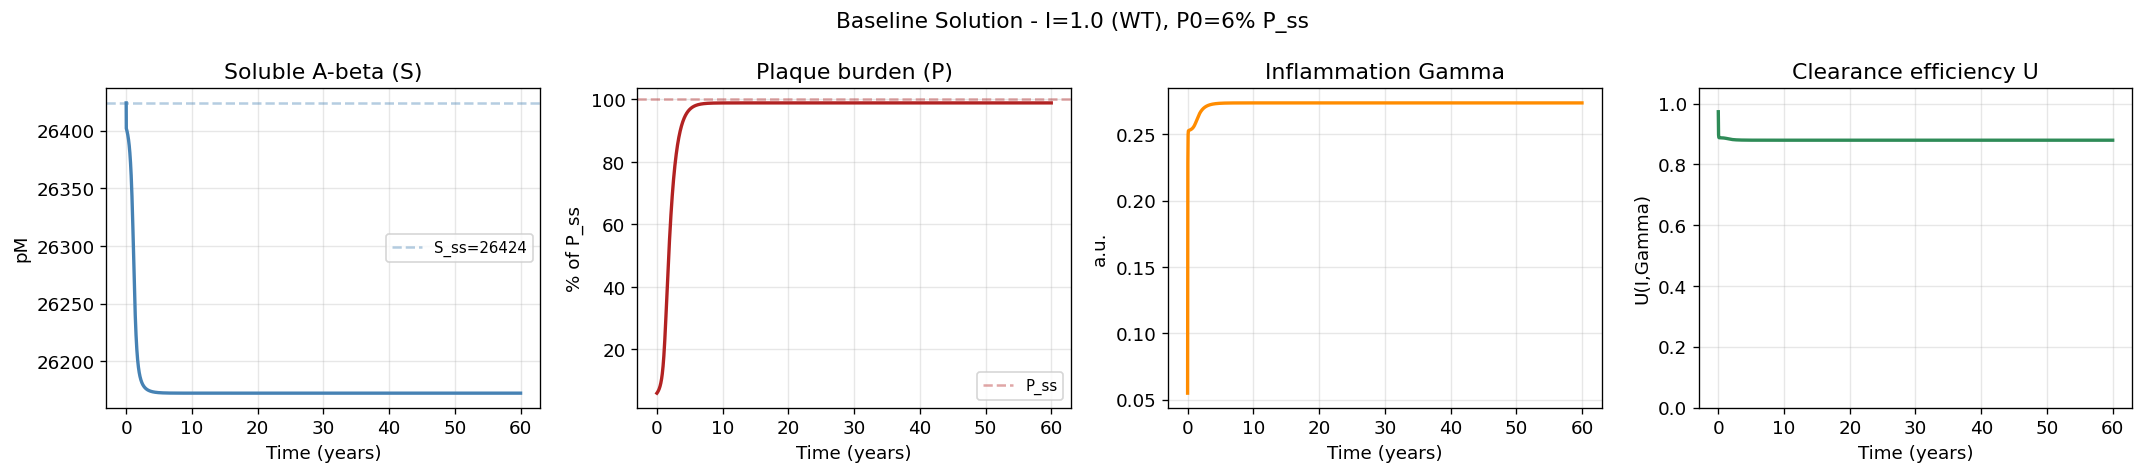


Baseline final values at t=60.0 yr:
  S_final = 26173 pM  (target ~26424)
  P_final = 1984239 pM  (99% of P_ss)
  G_final = 0.274
  U_final = 0.880


In [6]:
# Time grid: years (model uses hours internally)
HR_PER_YR = 8766.0
t_end_yr  = 60.0
n_pts     = 3000
t_eval    = np.linspace(0.0, t_end_yr * HR_PER_YR, n_pts)

# Initial condition: above WT saddle so system tips at I=I_WT
P0 = P_ss * 0.06
G0 = G_approx * 0.2
y0 = np.array([S_ss, P0, G0])

soln_base, success = lsoda(funcptr, y0, t_eval,
                           data=params_baseline,
                           rtol=1e-8, atol=1e-10)
if not success:
    print('WARNING: baseline solve did not fully converge')

t_yr = t_eval / HR_PER_YR
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Baseline Solution - I=1.0 (WT), P0=6% P_ss', fontsize=13)

axes[0].plot(t_yr, soln_base[:, 0], color='steelblue', lw=2)
axes[0].axhline(S_ss, color='steelblue', ls='--', alpha=0.4, label=f'S_ss={S_ss:.0f}')
axes[0].set(xlabel='Time (years)', ylabel='pM', title='Soluble A-beta (S)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(t_yr, soln_base[:, 1]/P_ss*100, color='firebrick', lw=2)
axes[1].axhline(100, color='firebrick', ls='--', alpha=0.4, label='P_ss')
axes[1].set(xlabel='Time (years)', ylabel='% of P_ss', title='Plaque burden (P)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(t_yr, soln_base[:, 2], color='darkorange', lw=2)
axes[2].set(xlabel='Time (years)', ylabel='a.u.', title='Inflammation Gamma')
axes[2].grid(alpha=0.3)

U_traj = U_0 * I_WT / (1.0 + lam * soln_base[:, 2])
axes[3].plot(t_yr, U_traj, color='seagreen', lw=2)
axes[3].set(xlabel='Time (years)', ylabel='U(I,Gamma)', title='Clearance efficiency U',
            ylim=(0, 1.05))
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nBaseline final values at t={t_end_yr} yr:')
print(f'  S_final = {soln_base[-1, 0]:.0f} pM  (target ~{S_ss:.0f})')
print(f'  P_final = {soln_base[-1, 1]:.0f} pM  ({soln_base[-1, 1]/P_ss*100:.0f}% of P_ss)')
print(f'  G_final = {soln_base[-1, 2]:.3f}')
print(f'  U_final = {U_traj[-1]:.3f}')

## 7. GSA Problem Definition

In [7]:
vl = 0.1    # 1/10 of baseline
vr = 10.0   # 10x of baseline

param_names = [
    'p_S', 'delta_S', 'k_seed', 'K', 'n',           # 0-4
    'k_rel', 'k_clr', 'U_0', 'lam',                  # 5-8
    'k_S', 'k_P', 'K_S', 'K_P',                      # 9-12
    'delta_G',                                        # 13
    'I',                                              # 14
]
assert len(param_names) == N_PARAMS

bounds = []
for name, bval in zip(param_names, params_baseline):
    if name == 'I':
        bounds.append([0.3, 1.0])     # physiological range
    elif name == 'n':
        bounds.append([1.0, 6.0])     # literature range
    elif name == 'U_0':
        bounds.append([0.1, 10.0])    # already normalized
    else:
        bounds.append([vl * bval, vr * bval])

problem = {
    'num_vars': N_PARAMS,
    'names'   : param_names,
    'bounds'  : bounds
}

print(f'GSA problem: {N_PARAMS} parameters')
print(f'  Standard range: [{vl}x, {vr}x] of baseline')
print(f'  Special: I=[0.3,1.0], n=[1,6], U_0=[0.1,10]')
for name, b in zip(param_names, bounds):
    print(f'    {name:10s}  [{b[0]:.3e}, {b[1]:.3e}]')

GSA problem: 15 parameters
  Standard range: [0.1x, 10.0x] of baseline
  Special: I=[0.3,1.0], n=[1,6], U_0=[0.1,10]
    p_S         [2.642e+03, 2.642e+05]
    delta_S     [1.000e-01, 1.000e+01]
    k_seed      [1.000e-03, 1.000e-01]
    K           [4.012e+04, 4.012e+06]
    n           [1.000e+00, 6.000e+00]
    k_rel       [1.000e-04, 1.000e-02]
    k_clr       [1.441e-05, 1.441e-03]
    U_0         [1.000e-01, 1.000e+01]
    lam         [5.000e-02, 5.000e+00]
    k_S         [3.000e-04, 3.000e-02]
    k_P         [3.000e-05, 3.000e-03]
    K_S         [2.642e+03, 2.642e+05]
    K_P         [2.006e+05, 2.006e+07]
    delta_G     [6.000e-04, 6.000e-02]
    I           [3.000e-01, 1.000e+00]


## 8. Saltelli Sampling

In [8]:
param_values = saltelli.sample(problem, N_BASE, calc_second_order=False)
n_runs = param_values.shape[0]
# Row count is (N_PARAMS + 2) * N_BASE because calc_second_order=False.
assert n_runs == (N_PARAMS + 2) * N_BASE, \
    f'expected {(N_PARAMS + 2) * N_BASE} rows, got {n_runs}'
print(f'Saltelli sample: {n_runs} parameter sets  '
      f'({N_BASE} x {N_PARAMS + 2} = {n_runs})')


/tmp/ipykernel_159/2300200264.py:1: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N_BASE, calc_second_order=False)


Saltelli sample: 69632 parameter sets  (4096 x 17 = 69632)


## 9. Parallel ODE Solves

Returns 4 outputs per run:
1. **S_final** - final soluble A$\beta$ at t=60 yr
2. **P_final** - final plaque burden
3. **G_final** - final inflammatory tone Gamma
4. **U_final** - final clearance efficiency U(I, Gamma)


In [9]:
P_ss_const = float(P_ss)

@nb.njit(parallel=True)
def solve_all(param_values, y0_arr, t_arr, fptr,
              U_0_idx, lam_idx, I_idx):
    '''Parallel Sobol runs. Returns S_final, P_final, G_final, U_final.'''
    n_runs = param_values.shape[0]
    Y_S = np.zeros(n_runs)
    Y_P = np.zeros(n_runs)
    Y_G = np.zeros(n_runs)
    Y_U = np.zeros(n_runs)

    for i in nb.prange(n_runs):
        soln, _ = lsoda(fptr, y0_arr, t_arr,
                        data=param_values[i], rtol=1e-7, atol=1e-9)
        S_f = soln[-1, 0]
        P_f = soln[-1, 1]
        G_f = soln[-1, 2]
        if S_f < 0.0: S_f = 0.0
        if P_f < 0.0: P_f = 0.0
        if G_f < 0.0: G_f = 0.0

        U_0_i = param_values[i, U_0_idx]
        lam_i = param_values[i, lam_idx]
        I_i   = param_values[i, I_idx]
        U_f   = U_0_i * I_i / (1.0 + lam_i * G_f)

        Y_S[i] = S_f
        Y_P[i] = P_f
        Y_G[i] = G_f
        Y_U[i] = U_f

    return Y_S, Y_P, Y_G, Y_U

# NRP_SWITCH: number of threads
import os
print(f'CPUs available: {os.cpu_count()}')
nb.set_num_threads(min(16, os.cpu_count()))   # always 16 (capped to actual CPUs if fewer)

# JIT warmup
print('Warming up Numba JIT (~30-60 s first time)...')
t0 = time.perf_counter()
_ = solve_all(param_values[:4].copy(), y0, t_eval, funcptr, 7, 8, 14)
print(f'Warmup done in {time.perf_counter()-t0:.1f} s')

# Full GSA run
print(f'Running {n_runs} solves...')
t0 = time.perf_counter()
Y_S, Y_P, Y_G, Y_U = solve_all(
    param_values, y0, t_eval, funcptr, 7, 8, 14)
elapsed = time.perf_counter() - t0
print(f'Done in {elapsed:.1f} s  ({elapsed/n_runs*1000:.1f} ms/solve)')

print()
print('Output ranges:')
print(f'  S_final : [{Y_S.min():.3e}, {Y_S.max():.3e}]')
print(f'  P_final : [{Y_P.min():.3e}, {Y_P.max():.3e}]')
print(f'  G_final : [{Y_G.min():.3e}, {Y_G.max():.3e}]')
print(f'  U_final : [{Y_U.min():.3e}, {Y_U.max():.3e}]')


CPUs available: 64
Warming up Numba JIT (~30-60 s first time)...
Warmup done in 0.7 s
Running 69632 solves...
Done in 1.5 s  (0.0 ms/solve)

Output ranges:
  S_final : [2.942e+02, 2.530e+06]
  P_final : [0.000e+00, 2.143e+10]
  G_final : [5.138e-05, 3.356e+01]
  U_final : [8.181e-04, 9.687e+00]


## Sanitize ODE outputs before Sobol analysis

This step is **distinct from clipping** (which comes next). Here we only repair
runs that returned non-finite values: with a large Sobol sample, a few parameter
combinations push the stiff solver into `inf`/`NaN` territory. Those entries are
set to zero so `sobol.analyze` receives a clean finite array. If the fraction of
bad runs exceeds ~2%, the parameter bounds may need tightening.

Clipping of the *finite* heavy upper tail is handled separately in the Sobol
step below, and its justification is documented in the **Clipping Robustness**
section near the end of the notebook and in Appendix A.


In [10]:
outputs = {'S': Y_S, 'P': Y_P, 'G': Y_G, 'U': Y_U}

for name, arr in outputs.items():
    valid = np.isfinite(arr)
    n_bad = (~valid).sum()
    print(f'  {name:8s} bad: {n_bad}/{len(arr)} ({100*n_bad/len(arr):.2f}%)')
    if n_bad > 0.02 * len(arr):
        print(f'    WARNING: >2% bad runs for {name} - consider tightening bounds.')
    arr[~valid] = 0.0

Y_S, Y_P, Y_G, Y_U = (outputs['S'], outputs['P'], outputs['G'], outputs['U'])


  S        bad: 0/69632 (0.00%)
  P        bad: 0/69632 (0.00%)
  G        bad: 0/69632 (0.00%)
  U        bad: 0/69632 (0.00%)


## 10. Sobol Analysis

### Why clip, and what exactly is clipped

Sobol indices are variance-based, so a few extreme runs can dominate the
decomposition. Each continuous output is therefore clipped at its 99th
percentile (lower bound 0) before `sobol.analyze`, except $U$, which is
bounded in $[0,\ \sim\!10]$ by construction and needs no clip.

| Output | Clipped? |
|--------|----------|
| $S$ (soluble)      | yes, 99th pct |
| $P$ (plaque)       | yes, 99th pct |
| $\Gamma$ (inflam.) | yes, 99th pct |
| $U$ (clearance)    | no |

Robustness to the clip level is checked in the **Clipping Robustness** section:
$S$, $\Gamma$, $U$ are insensitive to the threshold; $P$ shows mild dependence
(reported in Appendix A).

In [11]:
# Clip level for the continuous outputs. The robustness of the rankings to this
# choice is swept and plotted in the "Clipping Robustness" section (appendix).
CLIP_Q = 99   # percentile

def clip99(arr, q=CLIP_Q):
    """Clip at the q-th percentile (lower bound 0) to limit the influence of a
    few extreme runs on the variance-based Sobol indices. See the Clipping
    Robustness section for the justification figures."""
    return np.clip(arr, 0.0, np.percentile(arr, q))

# S, P, Gamma are clipped (heavy upper tails). U is bounded by construction, so
# it is not clipped.
Si_S = sobol.analyze(problem, clip99(Y_S), calc_second_order=False, print_to_console=False)
Si_P = sobol.analyze(problem, clip99(Y_P), calc_second_order=False, print_to_console=False)
Si_G = sobol.analyze(problem, clip99(Y_G), calc_second_order=False, print_to_console=False)
Si_U = sobol.analyze(problem, Y_U,          calc_second_order=False, print_to_console=False)

print('Sobol analysis complete.\n')
for label, Si in [('S_final', Si_S), ('P_final', Si_P),
                  ('G_final', Si_G), ('U_final', Si_U)]:
    top5 = np.argsort(Si['ST'])[::-1][:5]
    print(f'Top 5 - {label}:')
    for rank, idx in enumerate(top5):
        print(f'  {rank+1}. {param_names[idx]:10s}  ST={Si["ST"][idx]:.4f}  S1={Si["S1"][idx]:.4f}')
    print()


Sobol analysis complete.

Top 5 - S_final:
  1. delta_S     ST=0.9086  S1=0.7321
  2. p_S         ST=0.2676  S1=0.0954
  3. K           ST=0.0022  S1=-0.0004
  4. n           ST=0.0022  S1=0.0007
  5. k_seed      ST=0.0021  S1=-0.0000

Top 5 - P_final:
  1. delta_S     ST=0.5254  S1=0.0468
  2. k_clr       ST=0.4583  S1=0.0175
  3. n           ST=0.4096  S1=0.0206
  4. U_0         ST=0.3635  S1=0.0323
  5. K           ST=0.3415  S1=0.0178

Top 5 - G_final:
  1. delta_G     ST=0.7265  S1=0.4340
  2. k_S         ST=0.2127  S1=0.0550
  3. delta_S     ST=0.1735  S1=0.0396
  4. K_S         ST=0.1286  S1=0.0485
  5. p_S         ST=0.1260  S1=0.0266

Top 5 - U_final:
  1. U_0         ST=0.6543  S1=0.5475
  2. I           ST=0.2376  S1=0.1659
  3. delta_G     ST=0.0886  S1=0.0478
  4. k_S         ST=0.0518  S1=0.0240
  5. lam         ST=0.0507  S1=0.0281



## 11. LaTeX Labels

In [12]:
latex_labels = [
    '$p_S$',
    r'$\delta_S$',
    '$k_{seed}$',
    '$K$',
    '$n$',
    '$k_{rel}$',
    '$k_{clr}$',
    '$U_0$',
    r'$\lambda$',
    '$k_S$',
    '$k_P$',
    '$K_S$',
    '$K_P$',
    r'$\delta_\Gamma$',
    '$I$',
]
assert len(latex_labels) == N_PARAMS
print(f'{len(latex_labels)} LaTeX labels ready')

15 LaTeX labels ready


## 12. Bar Plot Helpers

In [13]:
def sobol_bar_plot_all(Si, all_labels, title, figsize=(12, 5)):
    '''Plot all parameters - overview/supplementary figures.'''
    n = len(all_labels)
    barWidth = 0.3
    r1 = np.arange(n)
    r2 = r1 + barWidth
    fig = plt.figure(figsize=figsize)
    plt.bar(r1, Si['ST'], width=barWidth, color=BAR_BLUE, edgecolor='black',
            yerr=Si['ST_conf'], capsize=4, label='Total Sensitivity ($S_T$)')
    plt.bar(r2, Si['S1'], width=barWidth, color=BAR_CYAN, edgecolor='black',
            yerr=Si['S1_conf'], capsize=4, label='1st Order Sensitivity ($S_1$)')
    plt.xticks([r + barWidth/2 for r in range(n)],
               all_labels, rotation='vertical', fontsize=11)
    plt.ylabel('Sensitivity Index')
    plt.title(title)
    plt.legend()
    plt.ylim(bottom=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig


def sobol_bar_plot(Si, all_labels, title, top_n=10, figsize=(10, 5)):
    '''Plot only top_n parameters by ST.'''
    sort_idx = np.argsort(Si['ST'])[::-1][:top_n]
    S1      = Si['S1'][sort_idx]
    ST      = Si['ST'][sort_idx]
    S1_conf = Si['S1_conf'][sort_idx]
    ST_conf = Si['ST_conf'][sort_idx]
    lbl     = [all_labels[i] for i in sort_idx]
    barWidth = 0.3
    r1 = np.arange(top_n)
    r2 = r1 + barWidth
    fig = plt.figure(figsize=figsize)
    plt.bar(r1, ST, width=barWidth, color=BAR_BLUE, edgecolor='black',
            yerr=ST_conf, capsize=5, label='Total Sensitivity ($S_T$)')
    plt.bar(r2, S1, width=barWidth, color=BAR_CYAN, edgecolor='black',
            yerr=S1_conf, capsize=5, label='1st Order Sensitivity ($S_1$)')
    plt.xticks([r + barWidth/2 for r in range(top_n)],
               lbl, rotation='vertical', fontsize=11)
    plt.ylabel('Sensitivity Index')
    plt.title(title)
    plt.legend()
    plt.ylim(bottom=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig

## 13. Plot - Final Soluble A-beta (S)

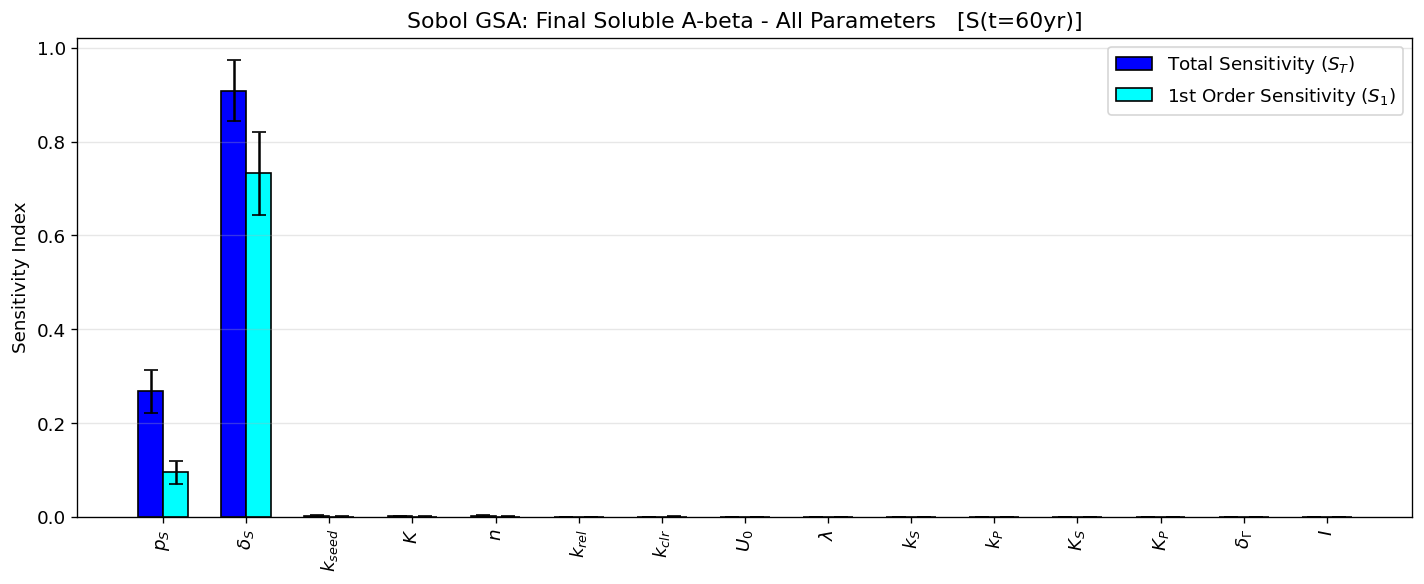

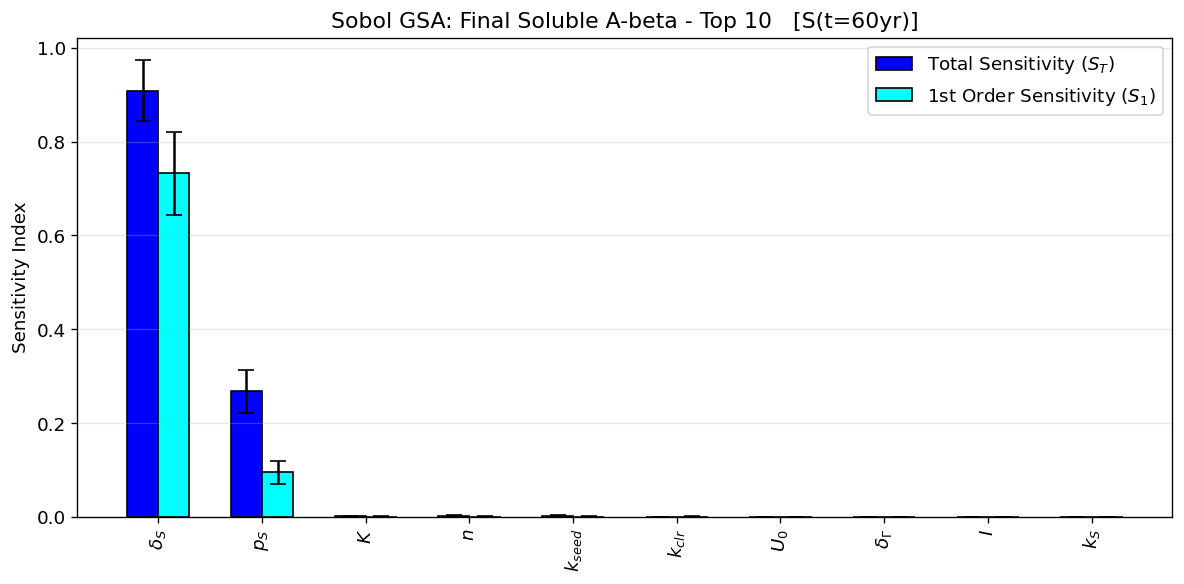

In [14]:
fig_S_all = sobol_bar_plot_all(
    Si_S, latex_labels,
    'Sobol GSA: Final Soluble A-beta - All Parameters   [S(t=60yr)]'
)
fig_S = sobol_bar_plot(
    Si_S, latex_labels,
    'Sobol GSA: Final Soluble A-beta - Top 10   [S(t=60yr)]'
)

## 14. Plot - Final Plaque Burden (P)

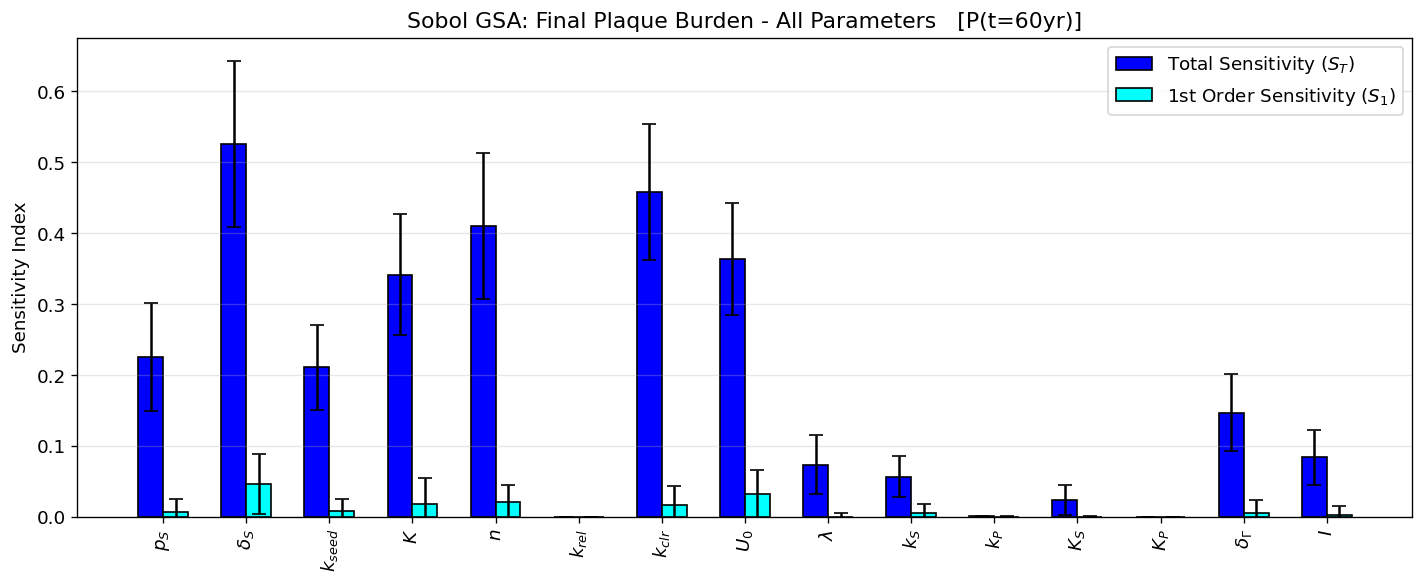

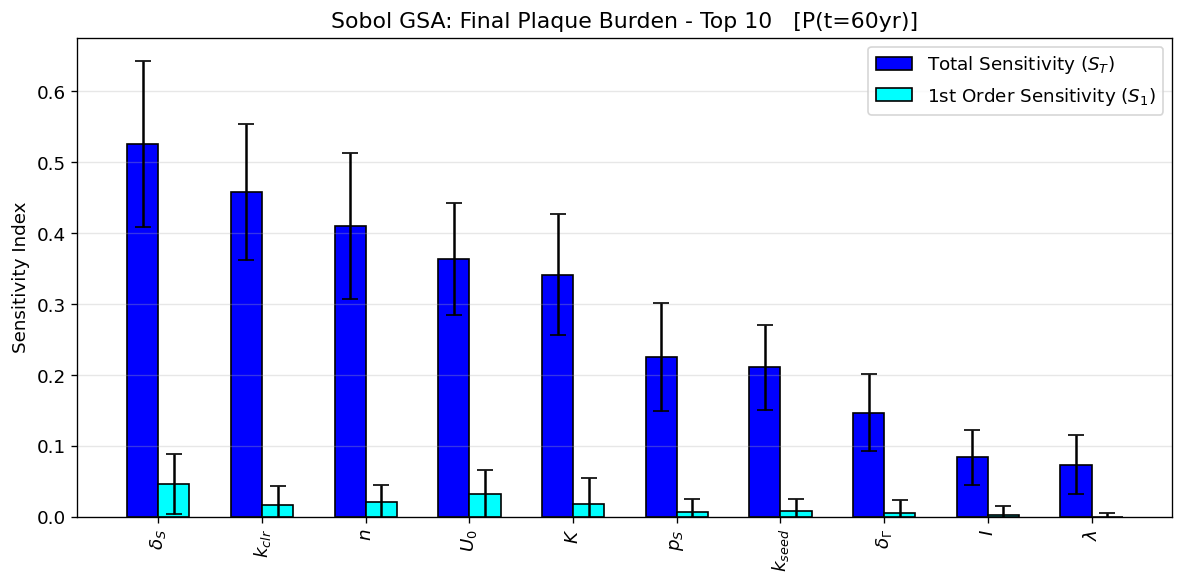

In [15]:
fig_P_all = sobol_bar_plot_all(
    Si_P, latex_labels,
    'Sobol GSA: Final Plaque Burden - All Parameters   [P(t=60yr)]'
)
fig_P = sobol_bar_plot(
    Si_P, latex_labels,
    'Sobol GSA: Final Plaque Burden - Top 10   [P(t=60yr)]'
)

## 15. Plot - Final Inflammation (Gamma)

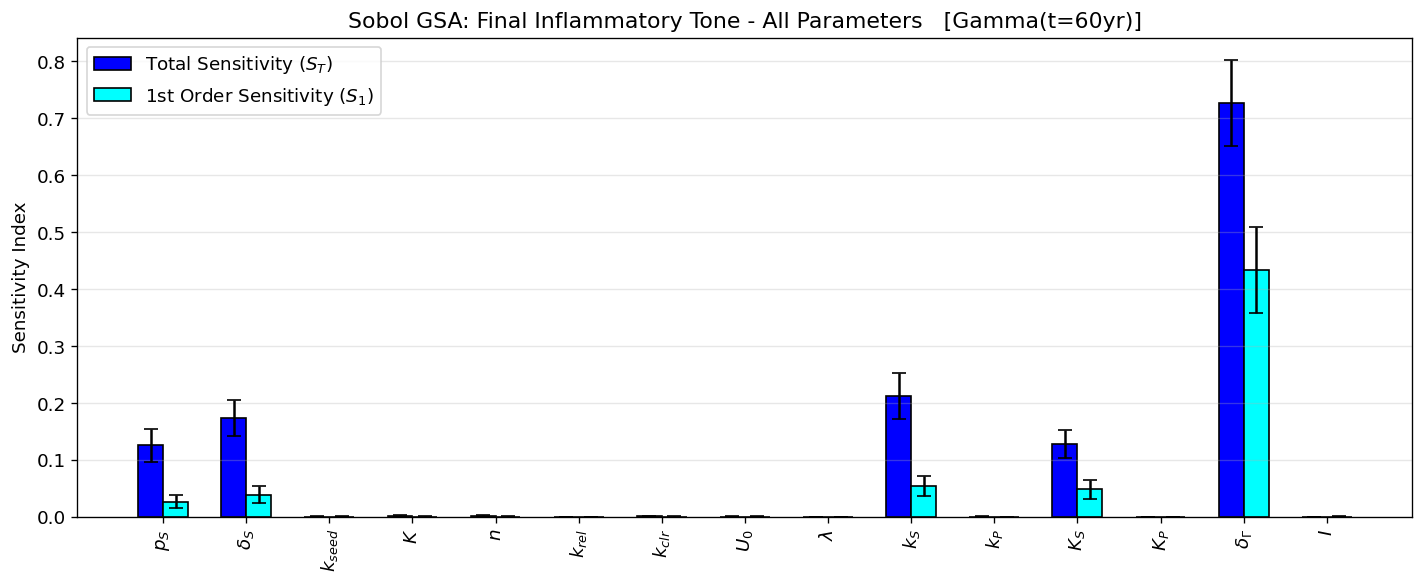

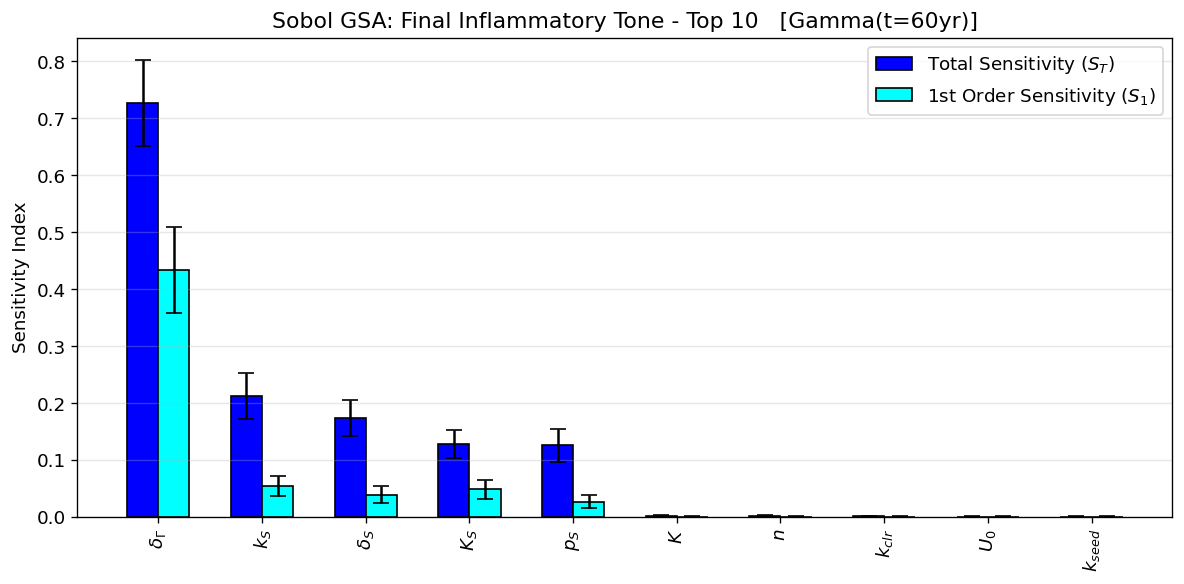

In [16]:
fig_G_all = sobol_bar_plot_all(
    Si_G, latex_labels,
    'Sobol GSA: Final Inflammatory Tone - All Parameters   [Gamma(t=60yr)]'
)
fig_G = sobol_bar_plot(
    Si_G, latex_labels,
    'Sobol GSA: Final Inflammatory Tone - Top 10   [Gamma(t=60yr)]'
)

## 16. Plot - Final Clearance Efficiency (U)

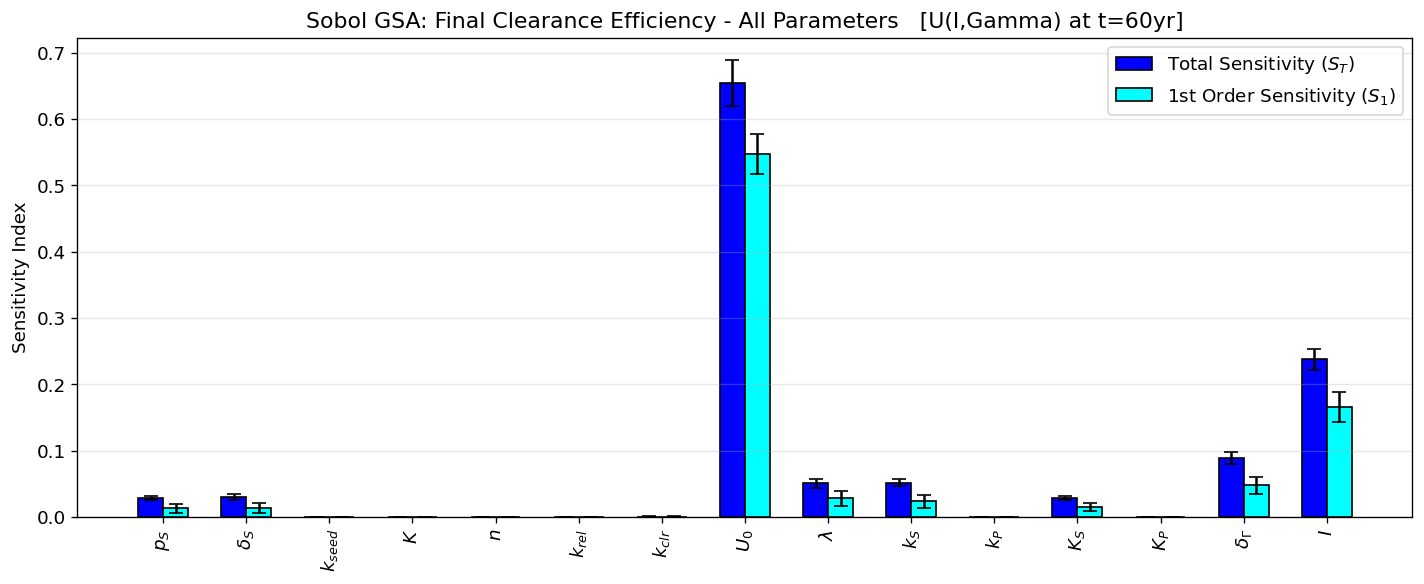

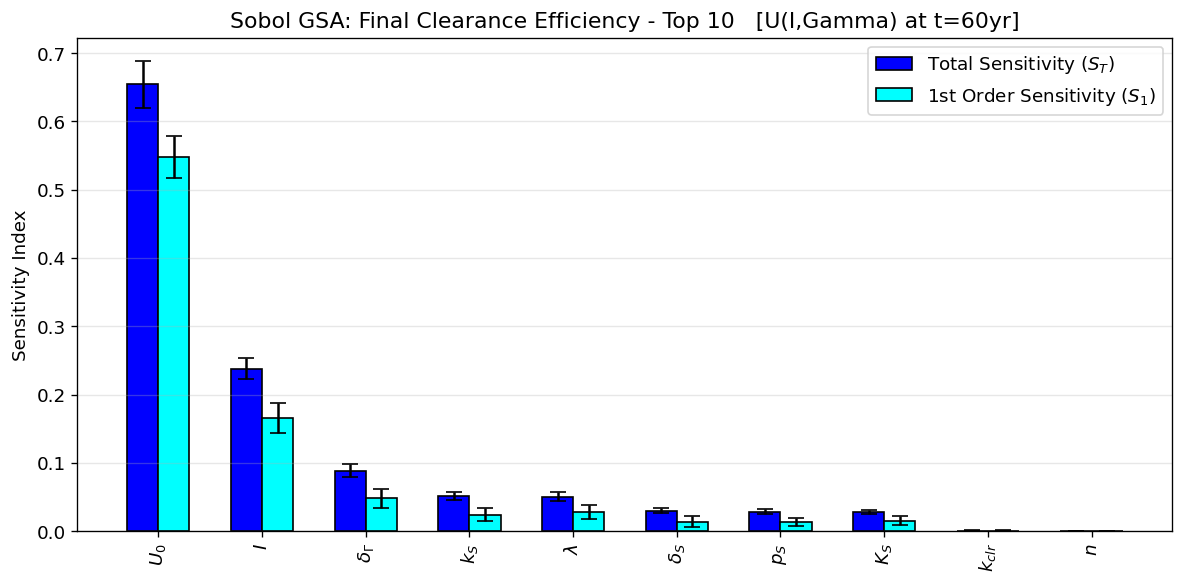

In [17]:
fig_U_all = sobol_bar_plot_all(
    Si_U, latex_labels,
    'Sobol GSA: Final Clearance Efficiency - All Parameters   [U(I,Gamma) at t=60yr]'
)
fig_U = sobol_bar_plot(
    Si_U, latex_labels,
    'Sobol GSA: Final Clearance Efficiency - Top 10   [U(I,Gamma) at t=60yr]'
)

## 17. Combined Heatmap - All Four Outputs


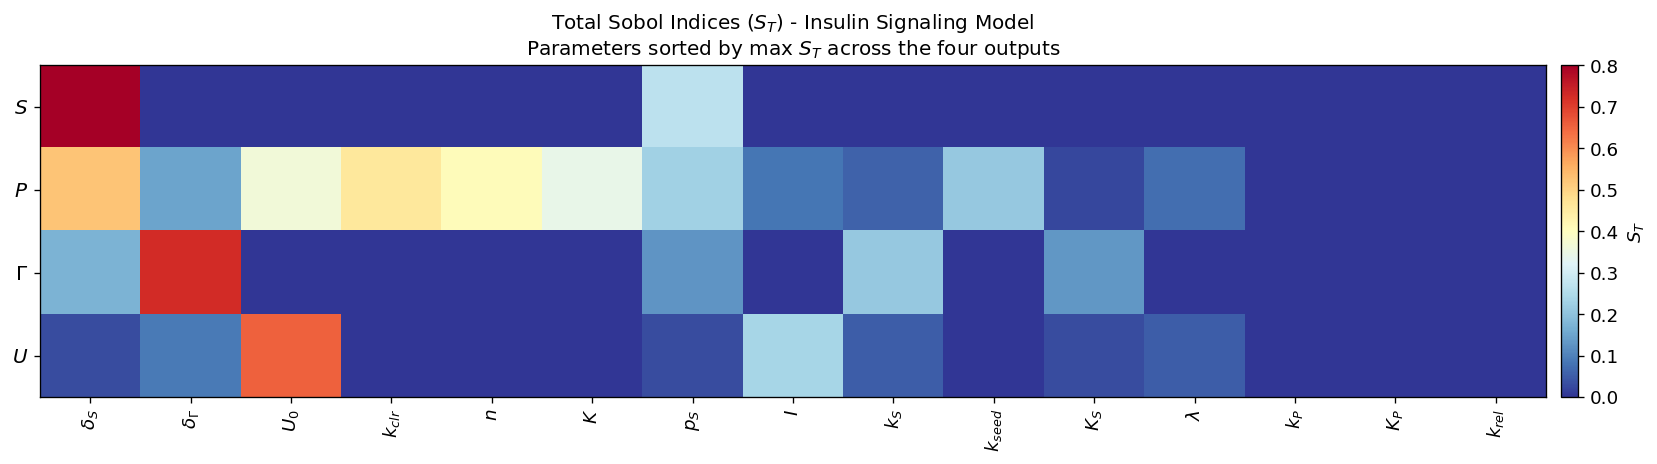

Top 10 parameters (max ST across all outputs):
   1. delta_S     max ST=0.9086  (S=0.909, P=0.525, G=0.173, U=0.030)
   2. delta_G     max ST=0.7265  (S=0.000, P=0.147, G=0.727, U=0.089)
   3. U_0         max ST=0.6543  (S=0.000, P=0.363, G=0.001, U=0.654)
   4. k_clr       max ST=0.4583  (S=0.001, P=0.458, G=0.001, U=0.001)
   5. n           max ST=0.4096  (S=0.002, P=0.410, G=0.002, U=0.000)
   6. K           max ST=0.3415  (S=0.002, P=0.342, G=0.003, U=0.000)
   7. p_S         max ST=0.2676  (S=0.268, P=0.225, G=0.126, U=0.029)
   8. I           max ST=0.2376  (S=0.000, P=0.084, G=0.000, U=0.238)
   9. k_S         max ST=0.2127  (S=0.000, P=0.057, G=0.213, U=0.052)
  10. k_seed      max ST=0.2111  (S=0.002, P=0.211, G=0.001, U=0.000)


In [18]:
ST_matrix = np.vstack([Si_S['ST'], Si_P['ST'], Si_G['ST'], Si_U['ST']])   # (4, N_PARAMS)
max_ST    = ST_matrix.max(axis=0)
sort_idx  = np.argsort(max_ST)[::-1]

fig_hm, ax = plt.subplots(figsize=(14, 4))
vmax = min(1.0, float(np.percentile(ST_matrix, 99)))
im = ax.imshow(ST_matrix[:, sort_idx], aspect='auto',
               cmap='RdYlBu_r', vmin=0, vmax=vmax)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['$S$', '$P$', '$\\Gamma$', '$U$'], fontsize=12)
ax.set_xticks(range(len(sort_idx)))
ax.set_xticklabels([latex_labels[i] for i in sort_idx], rotation=90, fontsize=11)
ax.set_title(
    'Total Sobol Indices ($S_T$) - Insulin Signaling Model\n'
    'Parameters sorted by max $S_T$ across the four outputs',
    fontsize=12)
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('$S_T$', fontsize=11)
plt.tight_layout()
plt.show()

print('Top 10 parameters (max ST across all outputs):')
for rank, idx in enumerate(sort_idx[:10]):
    print(f'  {rank+1:2d}. {param_names[idx]:10s}  '
          f'max ST={max_ST[idx]:.4f}  '
          f'(S={Si_S["ST"][idx]:.3f}, P={Si_P["ST"][idx]:.3f}, '
          f'G={Si_G["ST"][idx]:.3f}, U={Si_U["ST"][idx]:.3f})')


## 18. Clipping Robustness (Appendix figures)

These two figures justify the 99th-percentile clip used above and are included in Appendix A.

**Figure 1: Output distributions.** Histograms of the raw (unclipped) finite
outputs $S$, $P$, $\Gamma$, $U$, each with its 99th-percentile clip line marked.
This shows *why* clipping is needed: $P$ has a heavy upper tail extending
roughly two orders of magnitude beyond $P^\star$, so a few runs would
otherwise dominate $\mathrm{Var}(P)$. $S$ and $\Gamma$ show milder tails;
$U$ is bounded and needs no clip.

**Figure 2: Ranking robustness across clip levels.** For each continuous output
we recompute the total-order indices $S_T$ at several clip percentiles
(no clip, 99.9, 99, 97.5, 95) and plot $S_T$ of the leading parameters versus
clip level. Flat lines mean the ranking does not depend on the threshold.
$S$, $\Gamma$, and $U$ are flat; $P$ shows only mild movement, which is the
"mild dependence" reported in the text. The vertical guide marks the operating
choice (99th percentile).

Both figures are computed from arrays already in memory (no new ODE solves), so
this section is cheap to run after the main GSA.


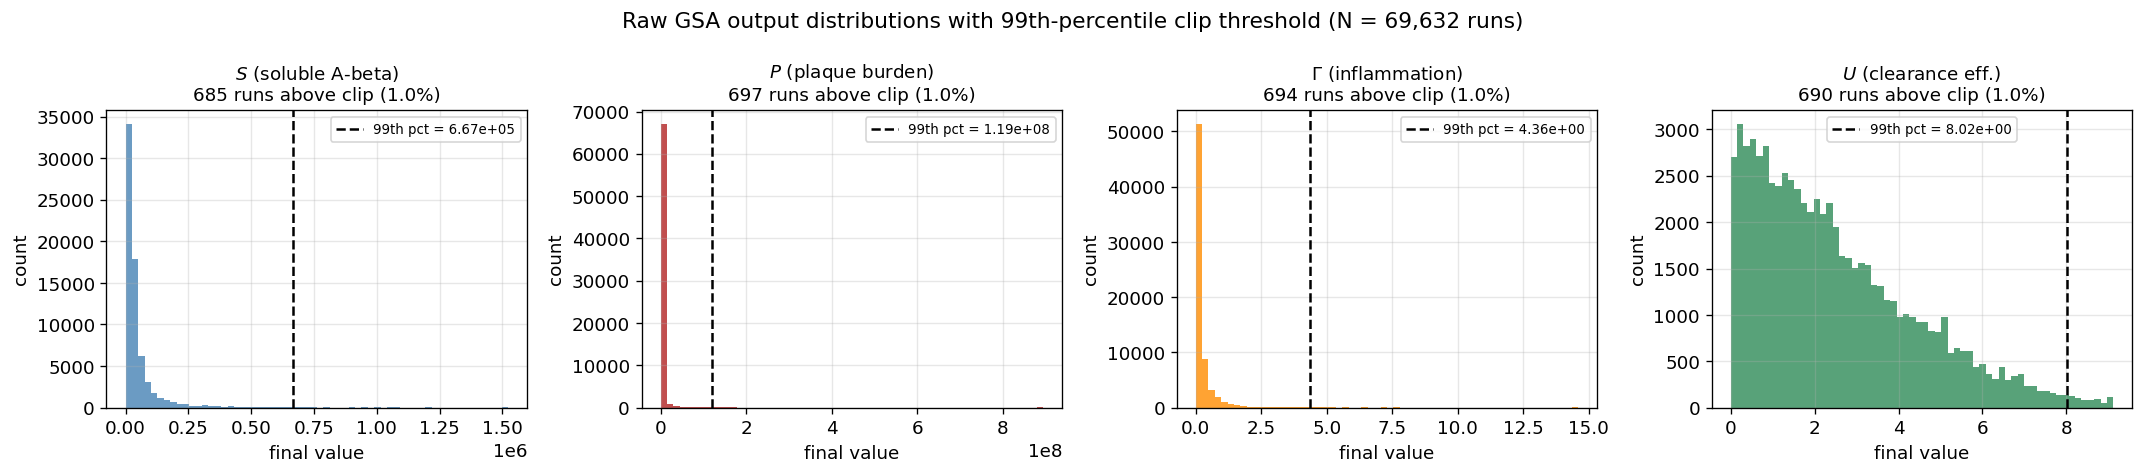

In [19]:
# --- Appendix Figure 1: raw output distributions with 99th-percentile clip line ---
# Uses the finite (sanitized) arrays Y_S, Y_P, Y_G, Y_U computed above.
clip_outputs = [
    ('$S$ (soluble A-beta)',  Y_S, 'steelblue'),
    ('$P$ (plaque burden)',   Y_P, 'firebrick'),
    ('$\\Gamma$ (inflammation)', Y_G, 'darkorange'),
    ('$U$ (clearance eff.)',  Y_U, 'seagreen'),
]

fig_clip_dist, axes = plt.subplots(1, 4, figsize=(18, 4))
fig_clip_dist.suptitle(
    'Raw GSA output distributions with 99th-percentile clip threshold '
    f'(N = {len(Y_P):,} runs)', fontsize=13)

for ax, (lbl, arr, col) in zip(axes, clip_outputs):
    finite = arr[np.isfinite(arr)]
    p99 = np.percentile(finite, 99)
    # Plot the bulk: cap the x-range at a high percentile so the tail does not
    # flatten the histogram, but annotate how many runs lie beyond the clip.
    x_hi = np.percentile(finite, 99.9)
    ax.hist(np.clip(finite, None, x_hi), bins=60, color=col, alpha=0.8,
            edgecolor='none')
    ax.axvline(p99, color='black', ls='--', lw=1.5,
               label=f'99th pct = {p99:.2e}')
    n_above = int((finite > p99).sum())
    ax.set_title(f'{lbl}\n{n_above} runs above clip ({100*n_above/len(finite):.1f}%)',
                 fontsize=11)
    ax.set_xlabel('final value')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


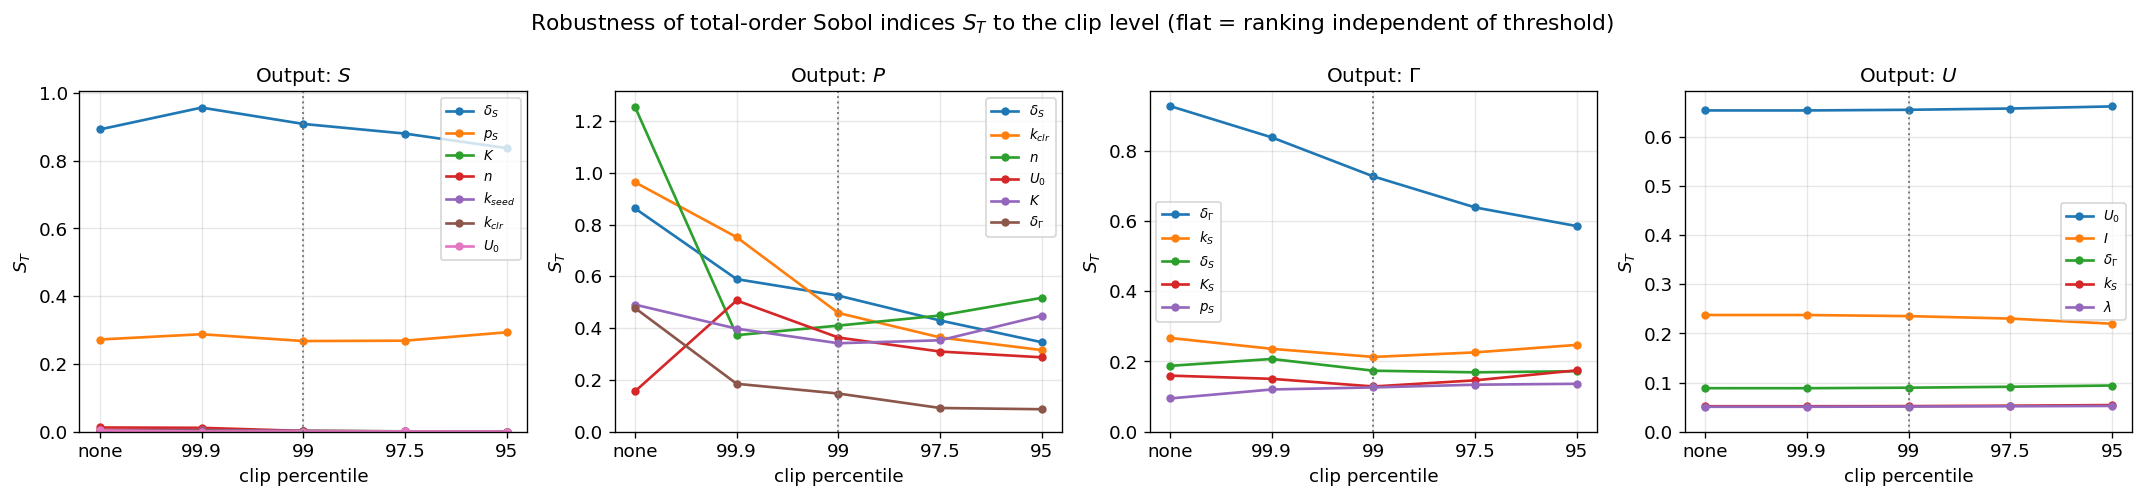

Max |ST(no clip) - ST(95th pct)| over leading parameters:
  $S$         max swing = 0.055
  $P$         max swing = 0.739
  $\Gamma$    max swing = 0.342
  $U$         max swing = 0.018


In [20]:
# --- Appendix Figure 2: ranking robustness across clip levels ---
# Recompute Sobol ST at several clip percentiles and show how the leading
# parameters' ST values move (or do not) with the threshold.
clip_levels = [100.0, 99.9, 99.0, 97.5, 95.0]   # 100 = no upper clip

def clip_at(arr, q):
    if q >= 100.0:
        return np.clip(arr, 0.0, None)
    return np.clip(arr, 0.0, np.percentile(arr, q))

robust_outputs = [
    ('$S$', Y_S), ('$P$', Y_P), ('$\\Gamma$', Y_G), ('$U$', Y_U),
]

# For each output, compute ST(level) for every parameter.
ST_by_output = {}
for lbl, arr in robust_outputs:
    ST_stack = []
    for q in clip_levels:
        Si_q = sobol.analyze(problem, clip_at(arr, q),
                             calc_second_order=False, print_to_console=False)
        ST_stack.append(Si_q['ST'])
    ST_by_output[lbl] = np.array(ST_stack)        # shape (len(clip_levels), N_PARAMS)

fig_clip_robust, axes = plt.subplots(1, 4, figsize=(18, 4.2))
fig_clip_robust.suptitle(
    'Robustness of total-order Sobol indices $S_T$ to the clip level '
    '(flat = ranking independent of threshold)', fontsize=13)

x = np.arange(len(clip_levels))
xtick_lbl = ['none' if q >= 100 else f'{q:g}' for q in clip_levels]

for ax, (lbl, arr) in zip(axes, robust_outputs):
    ST = ST_by_output[lbl]                          # (levels, params)
    # Show the parameters that are ever in the top 5 across the clip levels.
    top_any = np.unique(np.argsort(ST, axis=1)[:, ::-1][:, :5].ravel())
    # Order the legend by ST at the operating level (99th pct, index 2).
    op_idx = clip_levels.index(99.0)
    top_any = top_any[np.argsort(ST[op_idx, top_any])[::-1]]
    for p in top_any:
        ax.plot(x, ST[:, p], marker='o', ms=4, lw=1.6,
                label=latex_labels[p])
    ax.axvline(op_idx, color='gray', ls=':', lw=1.2)
    ax.set_title(f'Output: {lbl}', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_lbl)
    ax.set_xlabel('clip percentile')
    ax.set_ylabel('$S_T$')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, ncol=1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify the movement: max change in ST of any leading parameter across levels.
print('Max |ST(no clip) - ST(95th pct)| over leading parameters:')
for lbl, arr in robust_outputs:
    ST = ST_by_output[lbl]
    lead = np.argsort(ST[clip_levels.index(99.0)])[::-1][:5]
    swing = np.abs(ST[0, lead] - ST[-1, lead]).max()
    print(f'  {lbl:10s}  max swing = {swing:.3f}')


## 19. Save Figures


In [21]:
fig_S_all.savefig('GSA_insulin_S_all.pdf',     bbox_inches='tight')
fig_S.savefig('GSA_insulin_S_top10.pdf',        bbox_inches='tight')
fig_P_all.savefig('GSA_insulin_P_all.pdf',     bbox_inches='tight')
fig_P.savefig('GSA_insulin_P_top10.pdf',        bbox_inches='tight')
fig_G_all.savefig('GSA_insulin_G_all.pdf',     bbox_inches='tight')
fig_G.savefig('GSA_insulin_G_top10.pdf',        bbox_inches='tight')
fig_U_all.savefig('GSA_insulin_U_all.pdf',     bbox_inches='tight')
fig_U.savefig('GSA_insulin_U_top10.pdf',        bbox_inches='tight')
fig_hm.savefig('GSA_insulin_heatmap.pdf',      bbox_inches='tight')
# Clipping-justification figures for the appendix:
fig_clip_dist.savefig('GSA_insulin_clip_distributions.pdf', bbox_inches='tight')
fig_clip_robust.savefig('GSA_insulin_clip_robustness.pdf',  bbox_inches='tight')
print('All 11 figures saved (including 2 clipping-justification figures).')


All 11 figures saved (including 2 clipping-justification figures).
